<a href="https://colab.research.google.com/github/musowjanya/Datascience-Project/blob/main/L1T3_GeoSpatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium # interactive Visualization of the graph a library in seaborn

In [12]:
df = pd.read_csv("/content/Dataset .csv")
print(df.columns)
print(df.head())

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chin

In [13]:
df = df.dropna(subset=["Latitude", "Longitude"])

Visualization of a Map

In [14]:
map_center = [df["Latitude"].mean(), df["Longitude"].mean()]

restaurant_map = folium.Map(location=map_center, zoom_start=5)

# Add markers (limit to 500 for performance)
for i, row in df.head(500).iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        popup=f"{row['Restaurant Name']} | Rating: {row['Aggregate rating']}",
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(restaurant_map)

In [15]:
restaurant_map.save("restaurant_map.html")
print("Map saved as restaurant_map.html")

Map saved as restaurant_map.html


Distribution Analysis

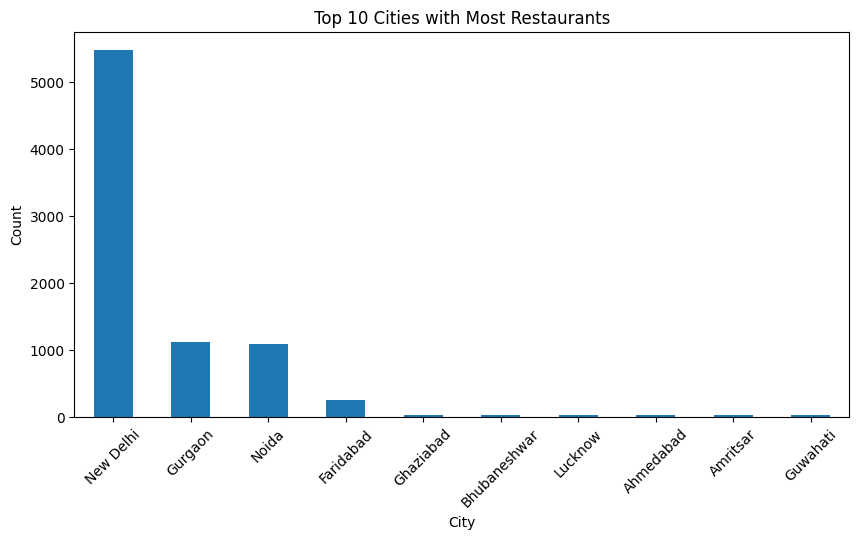

In [16]:
top_cities = df["City"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

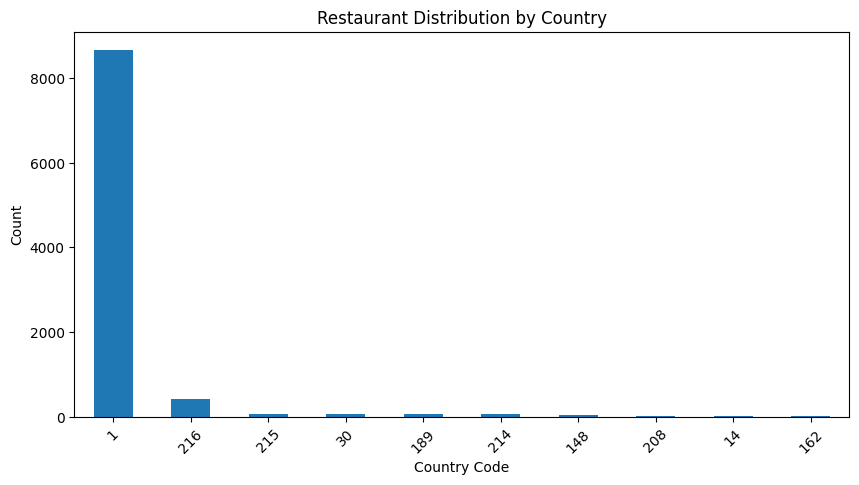

In [17]:
top_countries = df["Country Code"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Restaurant Distribution by Country")
plt.xlabel("Country Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Location Vs Rating analysis

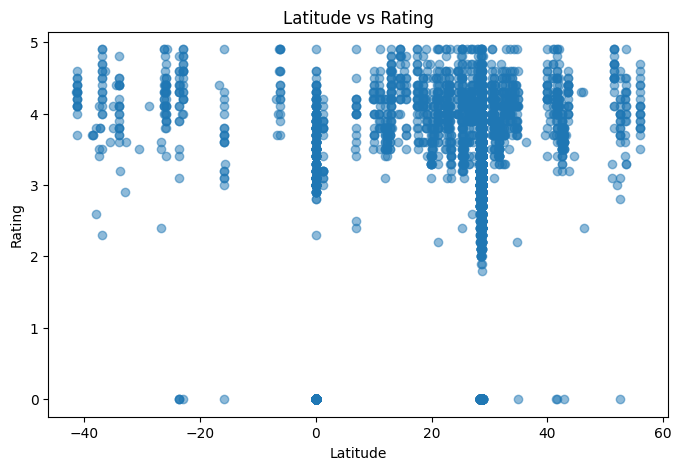

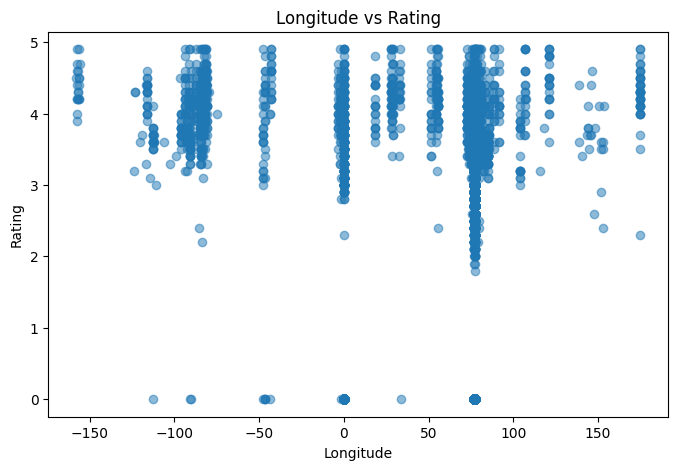

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df["Latitude"], df["Aggregate rating"], alpha=0.5)
plt.xlabel("Latitude")
plt.ylabel("Rating")
plt.title("Latitude vs Rating")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Longitude"], df["Aggregate rating"], alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Rating")
plt.title("Longitude vs Rating")
plt.show()

Corelation Analysis


Correlation Matrix:
                   Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


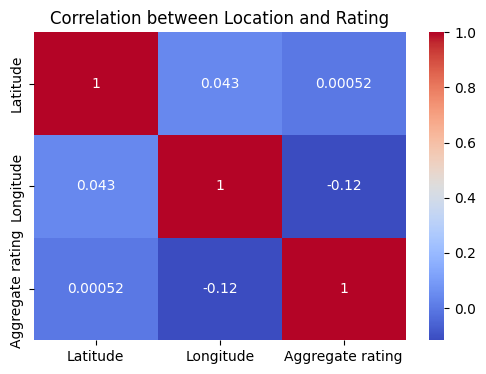

In [19]:
corr = df[["Latitude", "Longitude", "Aggregate rating"]].corr()

print("\nCorrelation Matrix:\n", corr)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Location and Rating")
plt.show()


Top Cities by Average Rating:
 City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


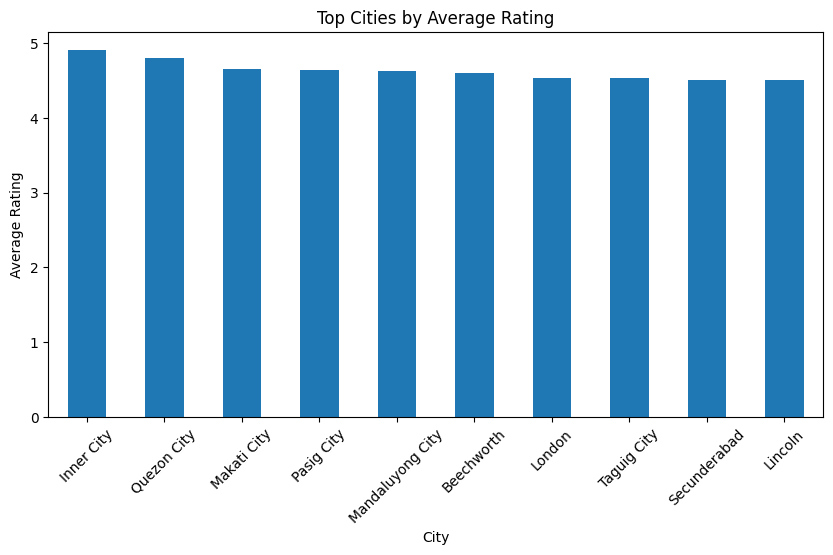

In [20]:
city_rating = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

print("\nTop Cities by Average Rating:\n", city_rating)

plt.figure(figsize=(10,5))
city_rating.plot(kind='bar')
plt.title("Top Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()